# Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astroquery.gaia import Gaia
import matplotlib as mpl

In [543]:
mpl.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman"],  # or "Computer Modern"
    "font.size": 14,

    "axes.labelsize": 14,
    "axes.titlesize": 16,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12,

    "mathtext.fontset": "cm",  # Computer Modern for LaTeX math
})

# Downloading Data

In [842]:
query = """
SELECT
    ra, dec,
    pmra, pmdec,
    parallax,
    parallax_over_error,
    phot_g_mean_mag,
    phot_bp_mean_mag,
    phot_rp_mean_mag,
    ruwe,
    teff_gspphot
FROM gaiadr3.gaia_source
WHERE CONTAINS(
    POINT('ICRS', ra, dec),
    CIRCLE('ICRS', 201.69121, -47.47686, 0.25)
)=1
AND parallax > 0
AND teff_gspphot IS NOT NULL
AND pmra IS NOT NULL
AND pmdec IS NOT NULL
"""

# AND parallax_over_error > 3
# AND ruwe > 1.4

job = Gaia.launch_job_async(query)
results = job.get_results()
df = results.to_pandas()

df.to_csv("ASTR4991_GAIA_Omega_Centauri_Filtered_Data.csv", index=False)

INFO: Query finished. [astroquery.utils.tap.core]


In [843]:
df

,ra,dec,pmra,pmdec,parallax,parallax_over_error,phot_g_mean_mag,phot_bp_mean_mag,phot_rp_mean_mag,ruwe,teff_gspphot
0,201.846230,-47.700071,-3.763372,-7.243171,0.193139,0.992935,18.484066,18.827444,17.957850,1.016548,5445.134766
1,201.848012,-47.692408,-3.135110,-7.565114,0.150826,1.618800,17.160141,17.564631,16.604647,1.062185,5283.884766
2,201.809769,-47.701033,-3.211784,-7.000247,0.565190,2.632087,18.668802,18.861034,18.005308,0.997000,5548.375977
3,201.804244,-47.693593,-3.367580,-6.594091,0.399406,1.855635,18.543880,18.908005,18.024679,1.115190,5586.001953
4,201.840379,-47.662234,-3.770748,-6.797395,0.179835,1.079478,18.109245,18.275072,17.460947,1.024499,5576.016602
...,...,...,...,...,...,...,...,...,...,...,...
20797,201.693530,-47.243623,-3.430524,-7.112517,0.123534,0.635404,17.999105,18.327869,17.529842,0.961071,5675.009277
20798,201.754718,-47.235323,-2.735116,-6.210302,0.159820,1.614965,17.333260,17.510202,16.655653,0.974578,5969.665039
20799,201.757660,-47.233871,-3.611332,-7.198118,0.094590,0.599183,18.018248,18.349081,17.561337,1.032280,5733.093262
20800,201.671354,-47.240666,-3.647850,-6.128671,0.172439,6.633501,12.234546,12.936944,11.421285,1.035638,4651.387207


# Reading Data

In [928]:
file_path_filtered = "/Users/ivarismartinez/Desktop/GAIA/ASTR4991_GAIA_Omega_Centauri_Filtered_Data.csv"

filtered_data = pd.read_csv(file_path_filtered)

print(filtered_data.columns)
print(len(filtered_data))

Index(['ra', 'dec', 'pmra', 'pmdec', 'parallax', 'parallax_over_error',
       'phot_g_mean_mag', 'phot_bp_mean_mag', 'phot_rp_mean_mag', 'ruwe',
       'teff_gspphot'],
      dtype='object')
20802


# Part 1: Globular Cluster Membership

In [929]:
# Choosing the systematic proper motion of the cluster with the most stars (Omega Centauri) by eye
pmra_center_by_eye = -3.5
pmdec_center_by_eye = -6.5

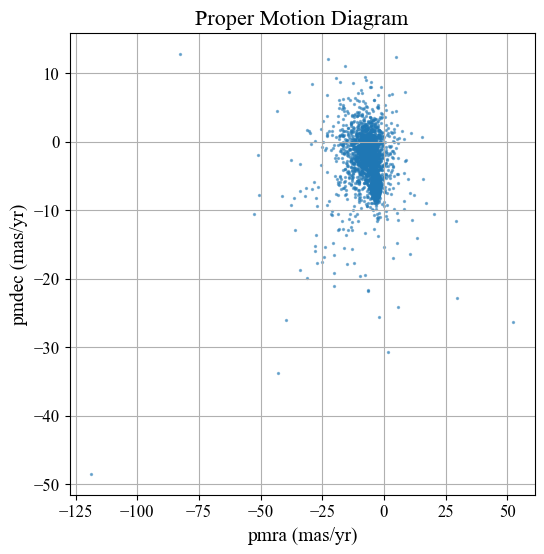

In [930]:
# Plotting the data
plt.figure(figsize=(6,6))
plt.scatter(filtered_data['pmra'], filtered_data['pmdec'], s=2, alpha=0.5)

plt.xlabel("pmra (mas/yr)")
plt.ylabel("pmdec (mas/yr)")
plt.title("Proper Motion Diagram")
plt.grid()

plt.savefig("Omega_Centauri_Unfiltered_Data.pdf", format="pdf", dpi=300, bbox_inches="tight")
plt.savefig("Omega_Centauri_Unfiltered_Data.png", format="png", dpi=300, bbox_inches="tight")

plt.show()

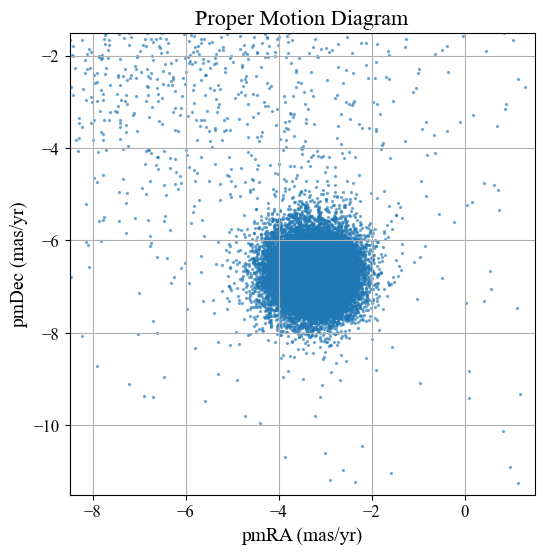

In [931]:
# Plotting the data
plt.figure(figsize=(6,6))
plt.scatter(filtered_data['pmra'], filtered_data['pmdec'], s=2, alpha=0.5)

plt.xlabel("pmRA (mas/yr)")
plt.ylabel("pmDec (mas/yr)")
plt.title("Proper Motion Diagram")
plt.xlim(pmra_center_by_eye - 5, pmra_center_by_eye + 5)
plt.ylim(pmdec_center_by_eye - 5, pmdec_center_by_eye + 5)
plt.grid()

plt.savefig("Omega_Centauri_Unfiltered_Data.pdf", format="pdf", dpi=300, bbox_inches="tight")
plt.savefig("Omega_Centauri_Unfiltered_Data.png", format="png", dpi=300, bbox_inches="tight")

plt.show()

In [932]:
# Filtering datapoints outside of the previous plot
filtered_data = filtered_data[
    (filtered_data['pmra'] > pmra_center_by_eye -5) & (filtered_data['pmra'] < pmra_center_by_eye + 5) &
    (filtered_data['pmdec'] > pmdec_center_by_eye-5) & (filtered_data['pmdec'] < pmdec_center_by_eye + 5)]

In [933]:
# Finding the actual systematic proper motion of the cluster with the most stars (Omega Centauri)
pmra_center = filtered_data['pmra'].median()
pmdec_center = filtered_data['pmdec'].median()

print(pmra_center, pmdec_center)

-3.272690282827364 -6.703224884033073


In [934]:
r = np.sqrt((filtered_data['pmra'] - pmra_center)**2 +
            (filtered_data['pmdec'] - pmdec_center)**2)

r_cut = np.percentile(r, 90)  # or 95
print(r_cut)

1.1446734716083935


In [935]:
# Choosing stars that are within a 1.5[] radius of the center (as stars within this radius seem to saturate the center found by the median)
radius = r_cut
mask = ((filtered_data['pmra'] - pmra_center)**2 + (filtered_data['pmdec'] - pmdec_center)**2) < radius**2
cluster_members = filtered_data[mask]


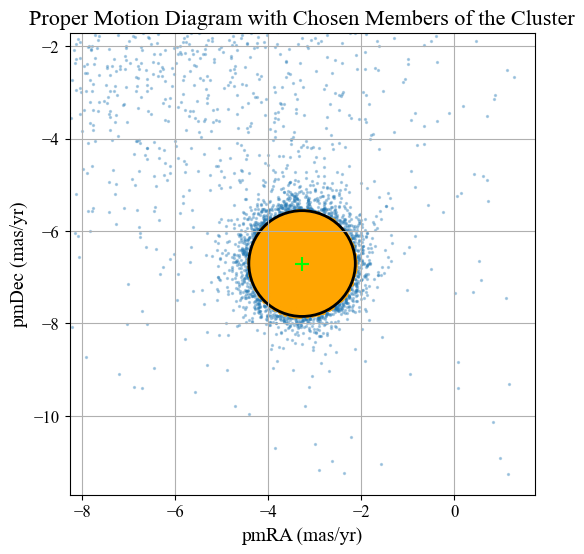

In [936]:
# Plotting the data again
plt.figure(figsize=(6,6))

# All stars
plt.scatter(filtered_data['pmra'], filtered_data['pmdec'], s=2, alpha=0.3)

# Cluster members
plt.scatter(cluster_members['pmra'], cluster_members['pmdec'], s=5, color='orange')

# Cutoff circle
circle = plt.Circle((pmra_center, pmdec_center), radius, color='black', fill=False, linewidth=2)
plt.gca().add_patch(circle)
plt.xlim(pmra_center - 5, pmra_center + 5)
plt.ylim(pmdec_center - 5, pmdec_center + 5)

# Labels
plt.xlabel("pmRA (mas/yr)")
plt.ylabel("pmDec (mas/yr)")
plt.title("Proper Motion Diagram with Chosen Members of the Cluster")
plt.scatter(pmra_center, pmdec_center, color='lime', marker='+', s=100, label="Center")
plt.grid()

plt.savefig("Omega_Centauri_Member_Cutoff.pdf", format="pdf", dpi=300, bbox_inches="tight")
plt.savefig("Omega_Centauri_Member_Cutoff.png", format="png", dpi=300, bbox_inches="tight")

plt.show()

In [937]:
# Saving the star data in a file
cluster_members.to_csv("/Users/ivarismartinez/Desktop/GAIA/OmegaCentauri_cluster_members.csv", index=False)

# Second Part

In [938]:
cluster_members = pd.read_csv('/Users/ivarismartinez/Desktop/GAIA/OmegaCentauri_cluster_members.csv')

In [939]:
# Calculating the BP-RP (color index)
cluster_members["bp_rp"] = (cluster_members["phot_bp_mean_mag"] - cluster_members["phot_rp_mean_mag"])

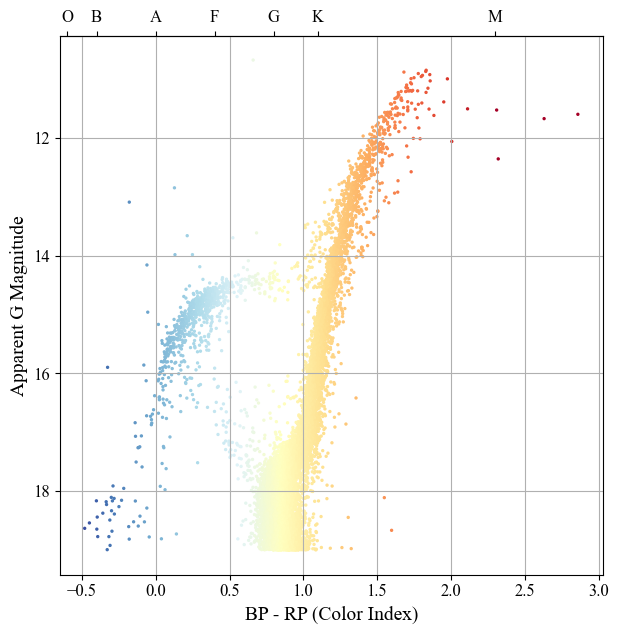

In [940]:
# Plotting Color-Magnitude Diagram vs. G
fig, ax = plt.subplots(figsize=(7,7))

sc = ax.scatter(cluster_members["bp_rp"], cluster_members["phot_g_mean_mag"], c=cluster_members["bp_rp"], cmap="RdYlBu_r", vmin=-0.6, vmax=2.3, s=2)
ax.set_xlabel("BP - RP (Color Index)")
ax.set_ylabel("Apparent G Magnitude")
ax.grid(True)

# Plotting spectral types
bp_rp_ticks = [-0.6, -0.4, 0, 0.4, 0.8, 1.1, 2.3]
spectral_labels = ["O", "B", "A", "F", "G", "K", "M"]
secax = ax.secondary_xaxis('top', functions=(lambda x: x, lambda x: x))
secax.set_xticks(bp_rp_ticks)
secax.set_xticklabels(spectral_labels)

ax.invert_yaxis()

plt.savefig("Omega_Centauri_Color_Magnitude_Plot.pdf", format="pdf", dpi=300, bbox_inches="tight")
plt.savefig("Omega_Centauri_Color_Magnitude_Plot.png", format="png", dpi=300, bbox_inches="tight")


plt.show()

In [941]:
# Calculating Absolute Magnitude in the Gaia "G" band
cluster_members["absolute_G"] = (cluster_members["phot_g_mean_mag"] + 5 * np.log10(cluster_members["parallax"]) - 10)

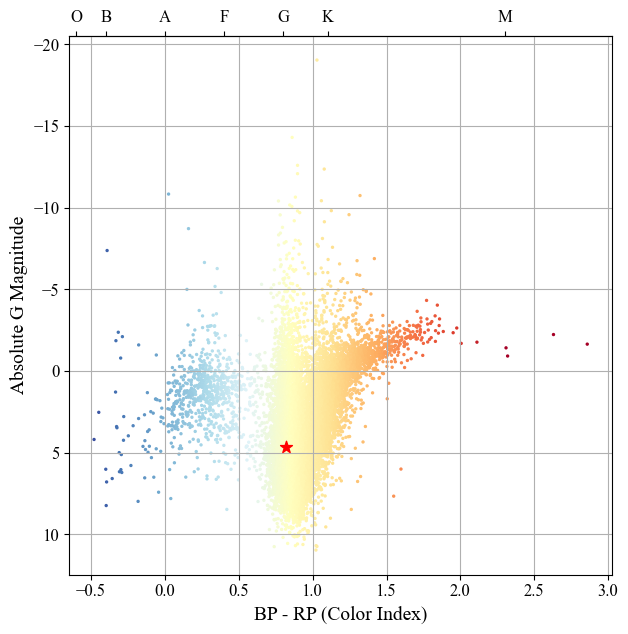

In [993]:
# Plotting Hertzsprung-Russell Diagram
fig, ax = plt.subplots(figsize=(7,7))

ax.scatter(cluster_members["bp_rp"], cluster_members["absolute_G"], c=cluster_members["bp_rp"], cmap="RdYlBu_r", vmin=-0.6, vmax=2.3, s=2)

ax.set_xlabel("BP - RP (Color Index)")
ax.set_ylabel("Absolute G Magnitude")
ax.grid(True)

# Plotting Sun
ax.scatter(0.82, 4.67, color='red', s=80, marker='*', label='Sun', zorder=5)

# Plotting spectral types
secax = ax.secondary_xaxis('top', functions=(lambda x: x, lambda x: x))
secax.set_xticks(bp_rp_ticks)
secax.set_xticklabels(spectral_labels)
# secax.set_xlabel("Spectral Type")

# To compare to literature graphs
ax.invert_yaxis()

plt.savefig("Omega_Centauri_Russell_Diagram.pdf", format="pdf", dpi=300, bbox_inches="tight")
plt.savefig("Omega_Centauri_Russell_Diagram.png", format="png", dpi=300, bbox_inches="tight")

plt.show()

In [943]:
# Saving the new data in a file
cluster_members.to_csv("/Users/ivarismartinez/Desktop/GAIA/OmegaCentauri_cluster_members_new_data.csv", index=False)

# Part 3

In [983]:
cluster_members = pd.read_csv('/Users/ivarismartinez/Desktop/GAIA/OmegaCentauri_cluster_members_new_data.csv')

In [984]:
# Calculating tangential velocities
cluster_members["v_ra"] = 4.74 * cluster_members["pmra"] / cluster_members["parallax"]
cluster_members["v_dec"] = 4.74 * cluster_members["pmdec"] / cluster_members["parallax"]

In [985]:
# Calculating velocity dispersions in each component
sigma_vra = cluster_members["v_ra"].std()
sigma_vdec = cluster_members["v_dec"].std()
print(sigma_vra, sigma_vdec)

# Calculating the one-dimensional velocity dispersion as the average of the two velocity dispersion
sigma_1D = (sigma_vra + sigma_vdec) / 2
print(sigma_1D)

14324.177510650448 30669.825256946024
22497.001383798237


In [996]:
# Calculating Mass
sigma = sigma_1D

# Constants
R = 7 * 3.086e16 # taking 10 pc 
G = 6.67e-11

# Mass equation
M = (5 * R * sigma**2) / G

# Changing to solar masses
M_solar = M / 1.989e30
print(M_solar)

4120525.6230915887


In [ ]:
# Changing to km/s
sigma = 15 * 1000

# Constants
R = 10 * 3.086e16 # changing to meters
G = 6.67e-11

# Mass equation
M = (5 * R * sigma**2) / G

# Changing to solar masses
M_solar = M / 1.989e30
print(M_solar)

2616904.2175744707


In [997]:
# Calculating escape velocity in km/s
v_escape = np.sqrt((2 * G * M) / R)
print(v_escape/1000)

71.14176489676228
